In [1]:
import os
os.chdir('../../../..')

In [2]:
import numpy as np
import polars as pl
import seaborn as sns
import chemiscope

from scipy.spatial.distance import squareform
from matplotlib import pyplot as plt
from sklearn.preprocessing import StandardScaler
from umap import UMAP
from sklearn.cluster import KMeans
from scipy.cluster.hierarchy import linkage as scipy_linkage, dendrogram
from scipy.cluster.hierarchy import cophenet, fcluster
from scipy.sparse.csgraph import laplacian
from scipy.linalg import eigh
from sklearn.metrics import silhouette_score, davies_bouldin_score
from scipy.spatial.distance import pdist, squareform

from src.datasets import MaterialsProject

from scripts.materials_project.euclidean_evaluation_pipeline import (
                                                           build_invariant_matrix
                                                           )
from src.helper_functions import create_chemiscope_viewer

In [3]:
mp = MaterialsProject(add_soap=False, add_acsf=False, sampling_strategy="stratified", stratify_on=["band_gap", "energy_above_hull"])
df = mp.load(limit=5000)

2026-04-03 09:56:00.133 | INFO     | src.datasets:load:1055 - Loading full cached Parquet data from data/Materials Project/materials.parquet...
2026-04-03 09:56:00.866 | INFO     | src.datasets:load:1085 - Sampling 5000 rows using stratified strategy...


In [5]:
feature_keys_1 = ['avg_neighbor_dist']
feature_keys_2 = ['avg_neighbor_dist', 'max_neighbor_dist']
feature_keys_3 = ['max_neighbor_dist']
feature_keys_4 = ['en']

k_1 = k_2 = k_3 = 3

raw_matrix = build_invariant_matrix(df, aggregated=True, feature_keys=feature_keys_1)
scaler = StandardScaler()
scaled_matrix = scaler.fit_transform(raw_matrix)
labels = KMeans(n_clusters=k_1, random_state=42).fit_predict(scaled_matrix)
df = df.with_columns(pl.Series("cluster_label", labels))
sil = silhouette_score(scaled_matrix, labels)
db = davies_bouldin_score(scaled_matrix, labels)
print(f"Silhouette Score: {sil:.4f}")
print(f"Davies-Bouldin Score: {db:.4f}")

Silhouette Score: 0.7482
Davies-Bouldin Score: 0.3579


In [6]:
reducer = 'UMAP'
create_chemiscope_viewer(df, scaled_matrix, labels=labels, reduction_method=reducer)

Running UMAP dimensionality reduction...


/Users/karlfindhansen/thesis/Anomaly-Detection-in-Molecular-and-Materials-Datasets/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


Converting Pymatgen structures to ASE Atoms for Chemiscope...
Assembling properties for Chemiscope...
Generating Chemiscope widget...
Saved Chemiscope input to: materials_UMAP_clustering.json
If the viewer does not open automatically, run `chemiscope show materials_UMAP_clustering.json`.


<ChemiscopeWidget(meta={'name': 'Materials Project - SOAP UMAP Clustering'}, settings={'map': {'x': {'property…

/Users/karlfindhansen/thesis/Anomaly-Detection-in-Molecular-and-Materials-Datasets/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


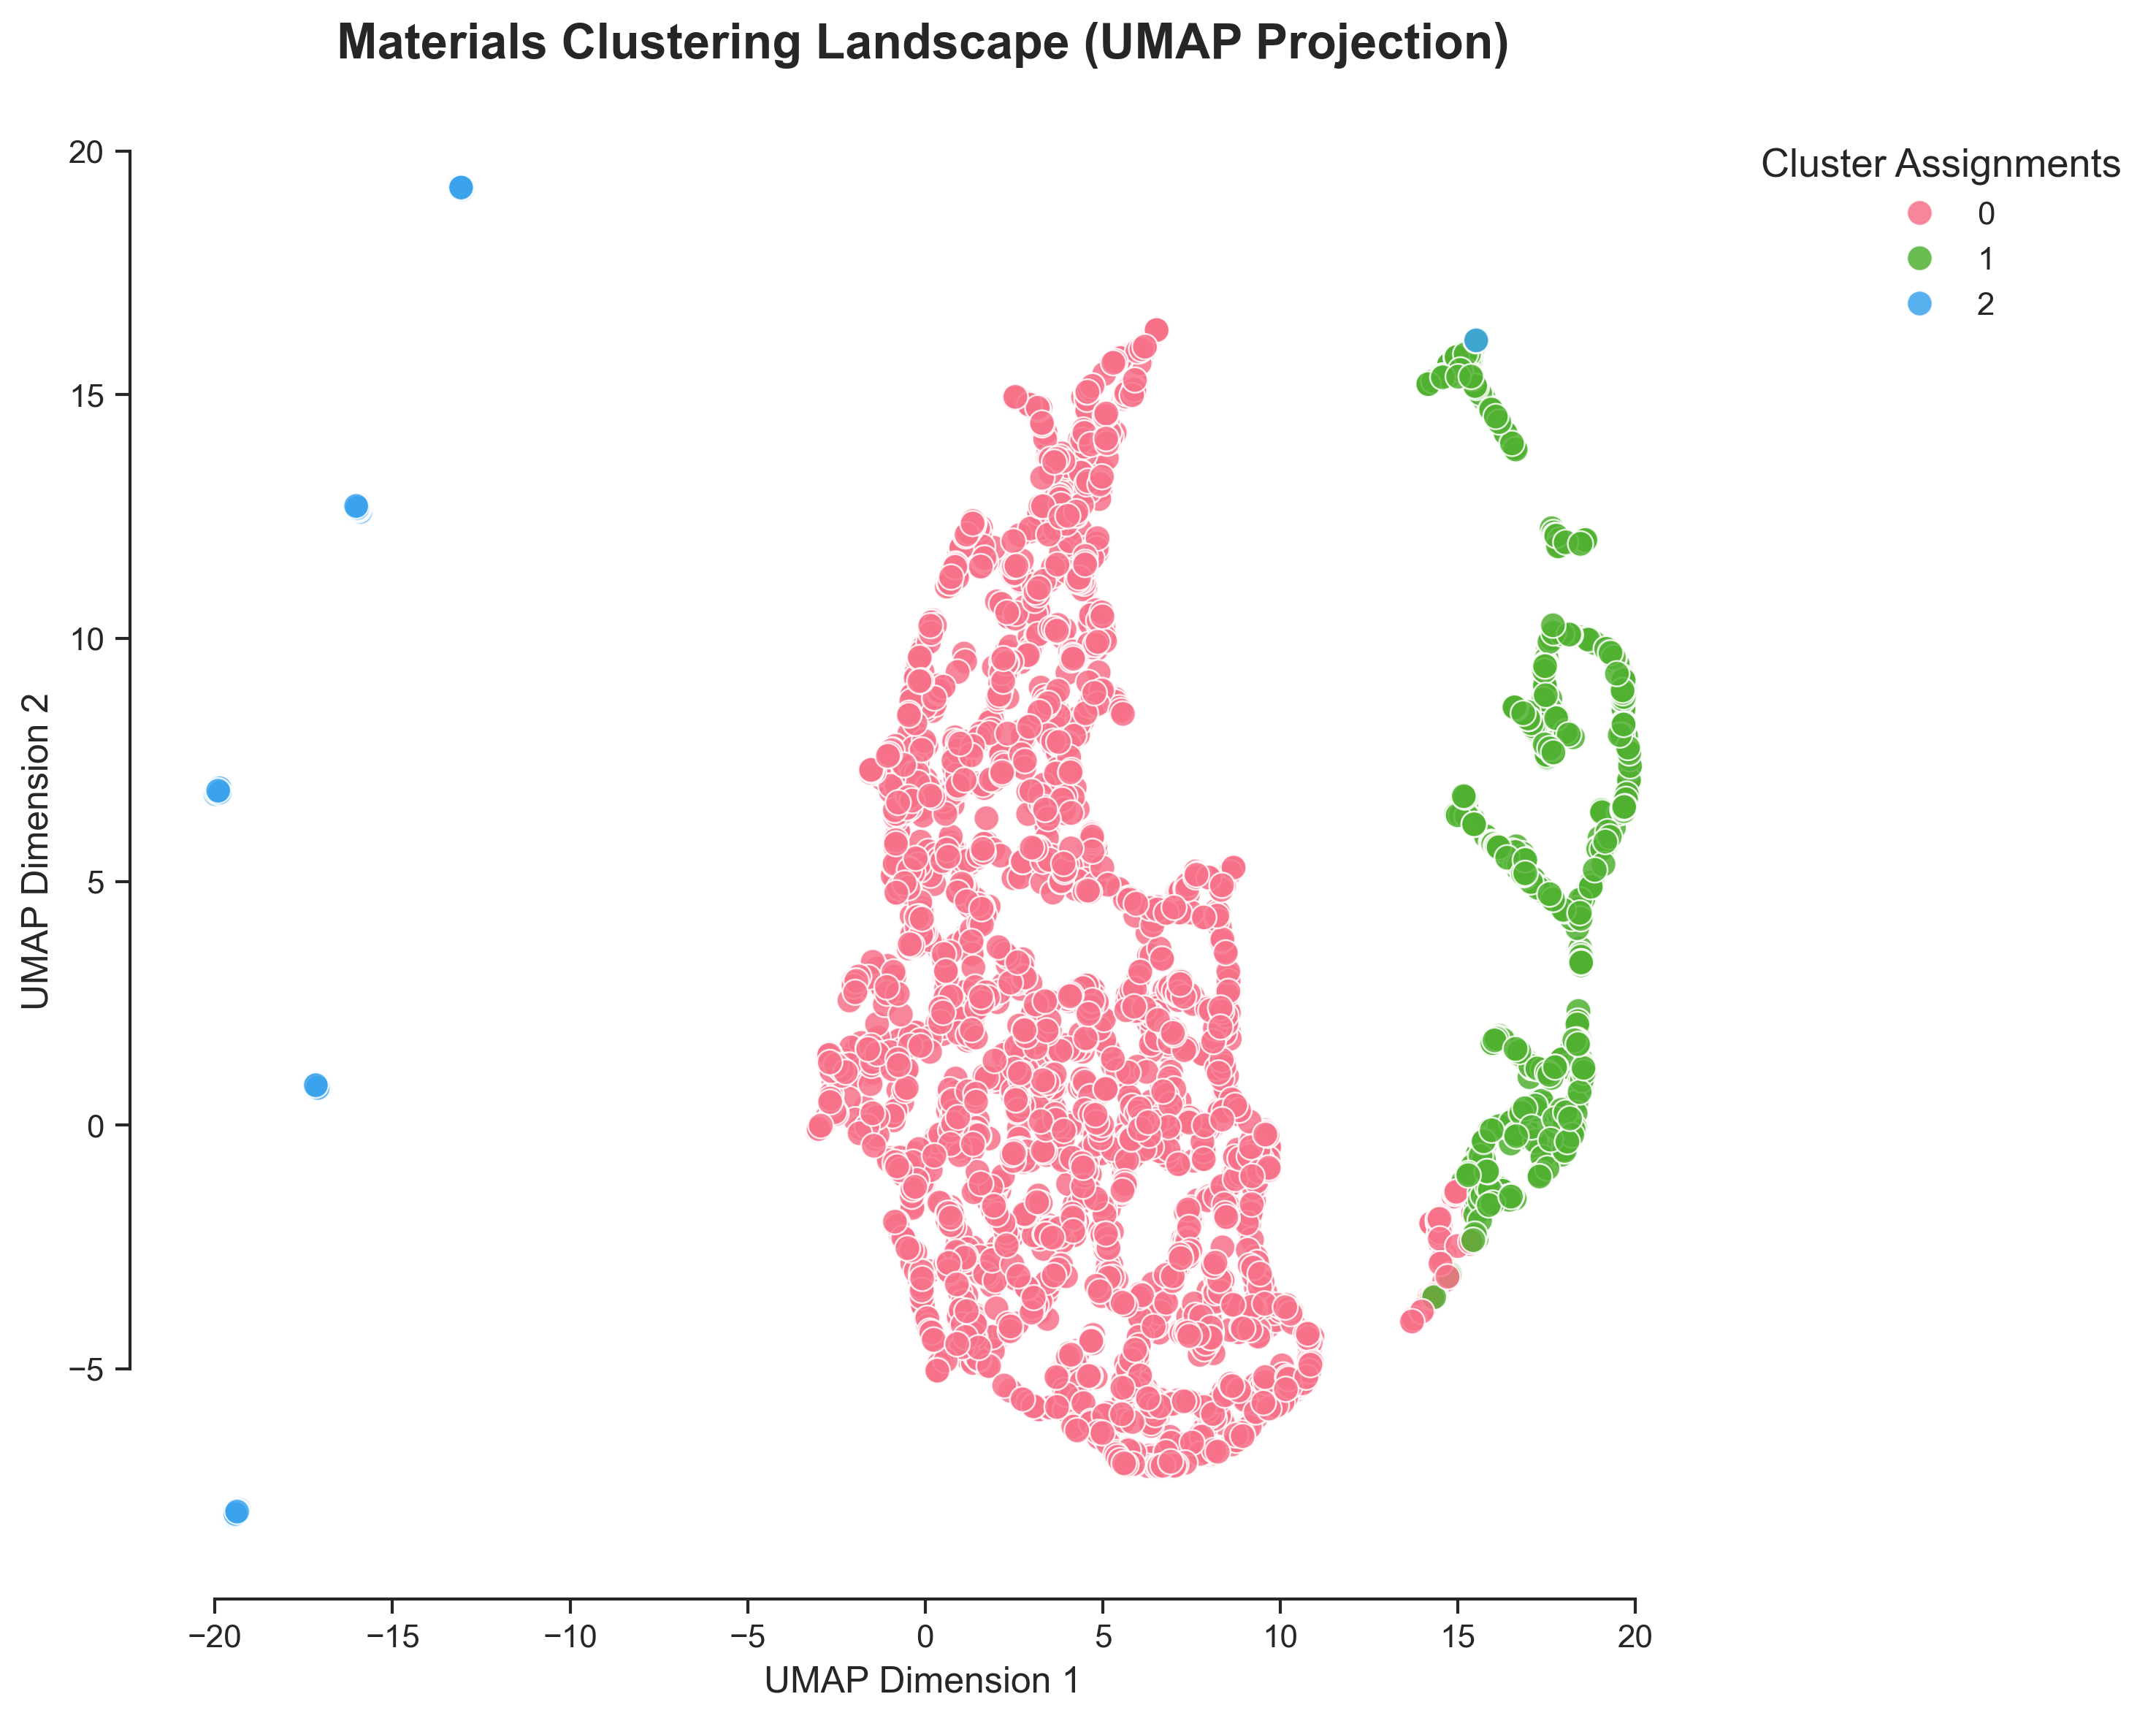

In [7]:
# 1. Setup UMAP (added n_neighbors and min_dist for better aesthetic tuning)
umap_reducer = UMAP(n_components=2, metric='euclidean', n_neighbors=15, min_dist=0.1, random_state=42)
umap_embedding = umap_reducer.fit_transform(scaled_matrix)

# 2. Setup Professional Plot Style
sns.set_theme(style="ticks", context="paper", font_scale=1.2)
fig, ax = plt.subplots(figsize=(10, 8), dpi=300) # High DPI makes it crisp for papers/presentations

# Convert labels to numpy array for boolean masking
labels = np.array(labels)
unique_labels = np.unique(labels)
n_clusters = len([l for l in unique_labels if l != -1])

# 3. Plot Noise First (so it stays in the background!)
noise_mask = (labels == -1)
if noise_mask.any():
    ax.scatter(
        umap_embedding[noise_mask, 0], 
        umap_embedding[noise_mask, 1], 
        c='#B0B0B0',        # Soft silver/grey
        s=15,               # Smaller size
        alpha=0.4,          # Highly transparent
        label='Noise (-1)',
        edgecolors='none'
    )

# 4. Plot the Valid Clusters
cluster_mask = (labels != -1)
if cluster_mask.any():
    # Use a vibrant, visually pleasing palette
    palette = sns.color_palette("husl", n_clusters)
    
    sns.scatterplot(
        x=umap_embedding[cluster_mask, 0], 
        y=umap_embedding[cluster_mask, 1], 
        hue=labels[cluster_mask], 
        palette=palette,
        s=70,               # Larger size for valid points
        alpha=0.85,         # Slight transparency to show density
        edgecolor='white',  # Adds a crisp outline to overlapping points
        linewidth=0.6,
        ax=ax,
        legend='full'
    )

# 5. Typography and Labels
ax.set_title('Materials Clustering Landscape (UMAP Projection)', 
             fontsize=16, fontweight='bold', pad=20)
ax.set_xlabel('UMAP Dimension 1', fontsize=12, fontweight='medium')
ax.set_ylabel('UMAP Dimension 2', fontsize=12, fontweight='medium')

# 6. Clean up the box/axes (Despine)
sns.despine(trim=True, offset=5)

# 7. Legend Formatting
# Move legend outside the plot, remove its ugly box
ax.legend(title="Cluster Assignments", 
          bbox_to_anchor=(1.02, 1), 
          loc='upper left', 
          frameon=False, 
          title_fontsize='13')

plt.tight_layout()

# Save it as a high-quality image (optional)
plt.savefig("figures/materials/clustering/kmeans/umap_clusters.png", dpi=300, bbox_inches='tight')

plt.show()

In [8]:
with pl.Config(set_tbl_cols=-1, set_tbl_width_chars=1000, set_tbl_rows=-1):
    df = df.with_columns(pl.Series("cluster_label", labels))
    
    for cluster in unique_labels:
        if cluster == -1:
            print(f"\nNoise Cluster (-1):")
        else:
            print(f"\nCluster {cluster}:")
        
        # Filter and sample
        cluster_samples = df.filter(pl.col("cluster_label") == cluster)
        
        # Ensure we don't try to sample more than available
        n_samples = min(25, len(cluster_samples))
        if n_samples > 0:
            print(cluster_samples.sample(n_samples))


Cluster 0:
shape: (25, 24)
┌─────────────┬───────────────────┬────────────────────┬─────────────┬─────────────────┬───────────────────────────┬──────────┬──────────┬─────────────────────────────────┬────────────────┬─────────────┬───────────┬───────────┬───────────┬───────────┬────────────┬────────────┬────────────┬─────────────┬───────────┬───────────────────┬─────────────────┬─────────────────┬───────────────┐
│ material_id ┆ formula_pretty    ┆ anonymized_formula ┆ max_en_diff ┆ energy_per_atom ┆ formation_energy_per_atom ┆ band_gap ┆ is_metal ┆ raw_structure                   ┆ crystal_system ┆ space_group ┆ density   ┆ a         ┆ b         ┆ c         ┆ alpha      ┆ beta       ┆ gamma      ┆ volume      ┆ num_sites ┆ energy_above_hull ┆ avg_bond_length ┆ max_bond_length ┆ cluster_label │
│ ---         ┆ ---               ┆ ---                ┆ ---         ┆ ---             ┆ ---                       ┆ ---      ┆ ---      ┆ ---                             ┆ ---            ┆ --- 

# Average within each cluster

In [31]:
def average_numeric_by_cluster(df: pl.DataFrame) -> pl.DataFrame:
    """
    Groups a Polars DataFrame by 'cluster_label' and returns 
    the mean of all numeric columns.
    """
    return (
        df.group_by("cluster_label")
        .agg(
            pl.col(pl.NUMERIC_DTYPES).mean()
        )
        .sort("cluster_label")
    )

cluster_averages = average_numeric_by_cluster(df)
with pl.Config(set_tbl_cols=-1, set_tbl_width_chars=1000, set_tbl_rows=-1):
    print(cluster_averages)


shape: (3, 17)
┌───────────────┬─────────────┬─────────────────┬───────────────────────────┬──────────┬──────────┬──────────┬──────────┬───────────┬───────────┬───────────┬───────────┬────────────┬───────────┬───────────────────┬─────────────────┬─────────────────┐
│ cluster_label ┆ max_en_diff ┆ energy_per_atom ┆ formation_energy_per_atom ┆ band_gap ┆ density  ┆ a        ┆ b        ┆ c         ┆ alpha     ┆ beta      ┆ gamma     ┆ volume     ┆ num_sites ┆ energy_above_hull ┆ avg_bond_length ┆ max_bond_length │
│ ---           ┆ ---         ┆ ---             ┆ ---                       ┆ ---      ┆ ---      ┆ ---      ┆ ---      ┆ ---       ┆ ---       ┆ ---       ┆ ---       ┆ ---        ┆ ---       ┆ ---               ┆ ---             ┆ ---             │
│ i32           ┆ f64         ┆ f64             ┆ f64                       ┆ f64      ┆ f64      ┆ f64      ┆ f64      ┆ f64       ┆ f64       ┆ f64       ┆ f64       ┆ f64        ┆ f64       ┆ f64               ┆ f64             ┆

/var/folders/_k/m1mygzyn5n7f9s1mcnb2hgxm0000gn/T/ipykernel_5820/4183903342.py:9: DeprecationWarning: `NUMERIC_DTYPES` was deprecated in version 1.0.0. Define your own data type groups or use the `polars.selectors` module for selecting columns of a certain data type.
  pl.col(pl.NUMERIC_DTYPES).mean()
